# NB07 - Rutas de regularización y selección de hiperparámetros con Titanic

Este notebook compara L2, L1 y Elastic Net usando validación cruzada. El objetivo es separar exploración visual de selección rigurosa.


In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks_2":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss, roc_auc_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold

from src.titanic_utils import RANDOM_STATE, load_processed_splits, plot_regularization_path, set_plot_style

set_plot_style()
data = load_processed_splits(DATA_DIR)
X_train = data["X_train_processed"]
X_test = data["X_test_processed"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]


## 1. Rutas completas de regularización

Primero vemos rutas para L2 y L1 sobre el mismo grid. `np.logspace(-3, 3, 13)` cubre seis órdenes de magnitud para `C`, suficiente para observar desde encogimiento extremo hasta penalización débil.


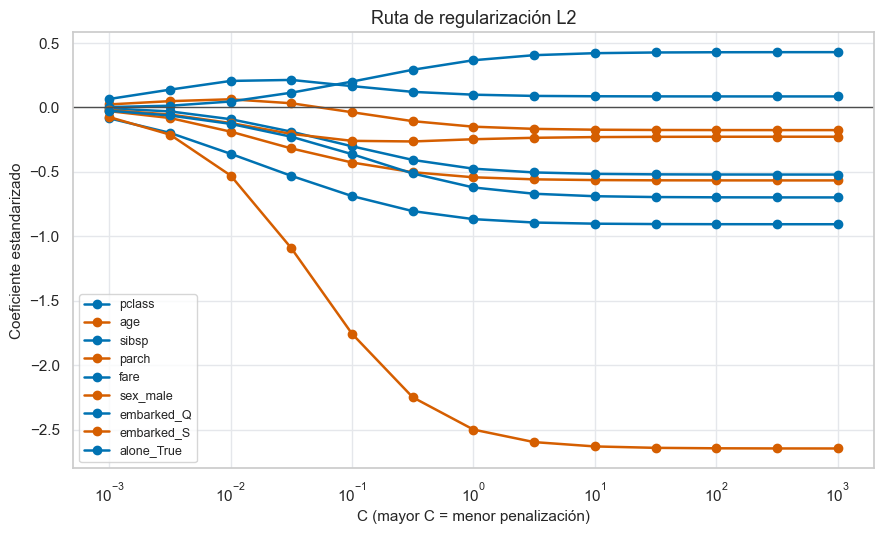

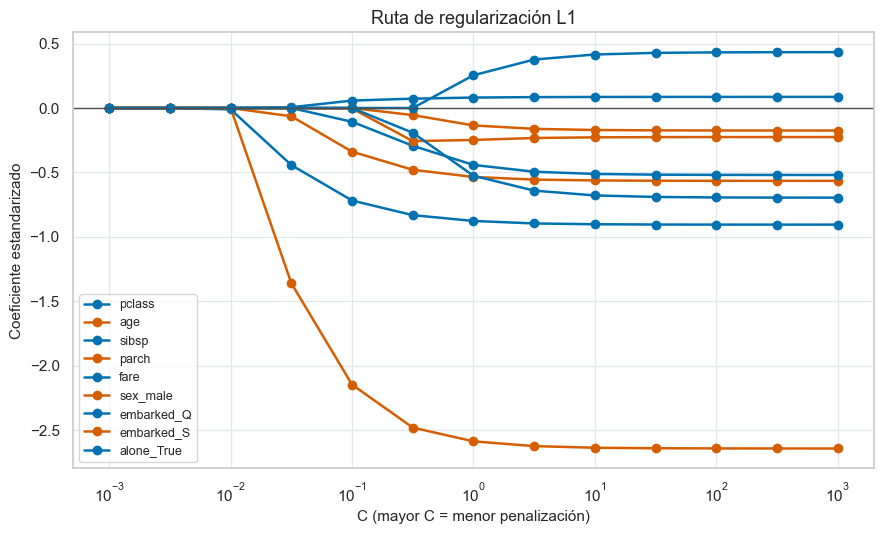

In [2]:
C_values = np.logspace(-3, 3, 13)
paths = {}
for penalty, solver in [("l2", "lbfgs"), ("l1", "saga")]:
    coefs = []
    for C in C_values:
        model = LogisticRegression(
            penalty=penalty,
            C=C,
            solver=solver,
            max_iter=12000,
            tol=1e-4,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train, y_train)
        coefs.append(model.coef_.ravel())
    paths[penalty] = np.vstack(coefs)

for penalty, coefs in paths.items():
    plot_regularization_path(
        C_values,
        coefs,
        feature_names,
        f"Ruta de regularización {penalty.upper()}",
    )
    plt.show()


## 2. Validación cruzada para L2, L1 y Elastic Net

Usamos `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` para preservar proporciones de clase en cada fold y reducir dependencia del orden de los datos. El score principal es ROC AUC porque evalúa ranking probabilístico sin fijar umbral.


In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
C_grid = np.logspace(-3, 3, 13)

searches = {
    "L2": GridSearchCV(
        LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=12000,
            random_state=RANDOM_STATE,
        ),
        param_grid={"C": C_grid},
        scoring="roc_auc",
        cv=cv,
        n_jobs=1,
    ),
    "L1": GridSearchCV(
        LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=12000,
            tol=1e-4,
            random_state=RANDOM_STATE,
        ),
        param_grid={"C": C_grid},
        scoring="roc_auc",
        cv=cv,
        n_jobs=1,
    ),
    "Elastic Net": GridSearchCV(
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            max_iter=12000,
            tol=1e-4,
            random_state=RANDOM_STATE,
        ),
        param_grid={"C": C_grid, "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
        scoring="roc_auc",
        cv=cv,
        n_jobs=1,
    ),
}

summary_rows = []
for name, search in searches.items():
    search.fit(X_train, y_train)
    summary_rows.append(
        {
            "modelo": name,
            "mejor_auc_cv": search.best_score_,
            "mejores_hiperparametros": search.best_params_,
        }
    )

cv_summary = pd.DataFrame(summary_rows)
display(cv_summary)


,modelo,mejor_auc_cv,mejores_hiperparametros
0,L2,0.8499,{'C': 0.31622776601683794}
1,L1,0.8514,{'C': 0.31622776601683794}
2,Elastic Net,0.8504,"{'C': 0.31622776601683794, 'l1_ratio': 0.9}"


## 3. Visualización de la búsqueda Elastic Net

La grilla de Elastic Net cruza `C` y `l1_ratio`. El mapa permite ver si el desempeño depende más de la fuerza total de penalización o de la mezcla L1/L2.


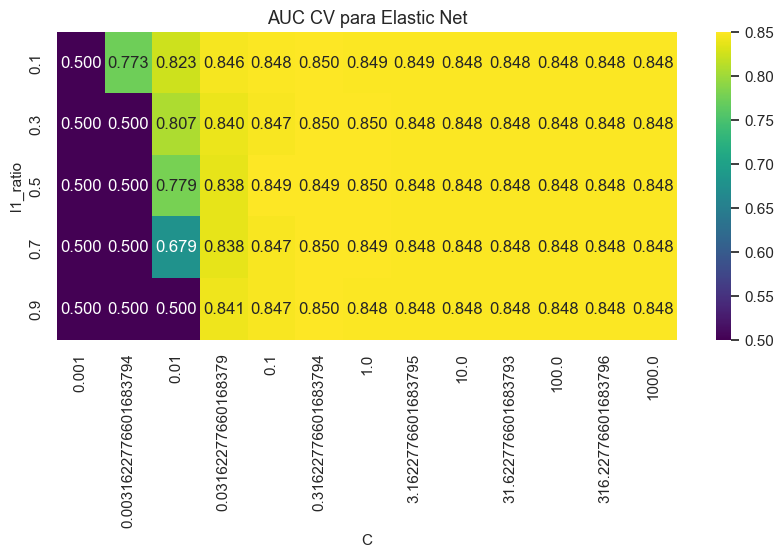

In [4]:
elastic_cv = pd.DataFrame(searches["Elastic Net"].cv_results_)
elastic_cv["C"] = elastic_cv["param_C"].astype(float)
elastic_cv["l1_ratio"] = elastic_cv["param_l1_ratio"].astype(float)
heatmap_data = elastic_cv.pivot(index="l1_ratio", columns="C", values="mean_test_score")

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="viridis", ax=ax)
ax.set_title("AUC CV para Elastic Net")
ax.set_xlabel("C")
ax.set_ylabel("l1_ratio")
plt.show()


## 4. Comparación final de penaltis

Ahora evaluamos cada mejor estimador en test. Esta tabla es la comparación honesta final del notebook, porque el test no se usó para elegir hiperparámetros.


In [5]:
test_rows = []
for name, search in searches.items():
    model = search.best_estimator_
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    test_rows.append(
        {
            "modelo": name,
            "auc_test": roc_auc_score(y_test, prob),
            "log_loss_test": log_loss(y_test, prob),
            "accuracy_test": accuracy_score(y_test, pred),
            "f1_test": f1_score(y_test, pred),
            "variables_no_cero": int((np.abs(model.coef_.ravel()) > 1e-6).sum()),
        }
    )

test_summary = pd.DataFrame(test_rows).sort_values("auc_test", ascending=False)
display(test_summary)


,modelo,auc_test,log_loss_test,accuracy_test,f1_test,variables_no_cero
0,L2,0.8542,0.4474,0.7985,0.73,9
2,Elastic Net,0.8537,0.4467,0.7985,0.73,8
1,L1,0.8528,0.4472,0.7985,0.73,8


## 5. Coordinate descent

Bibliotecas como `glmnet` calculan rutas completas con coordinate descent. scikit-learn usa otros solvers, como LBFGS y SAGA, pero la idea de comparar soluciones a lo largo de una ruta de regularización sigue siendo la misma: estudiar cómo cambian coeficientes y desempeño cuando varía la penalización.


## Resumen y conexión con la literatura

La selección de hiperparámetros debe ocurrir dentro de validación cruzada. Friedman, Hastie y Tibshirani popularizaron rutas eficientes para GLM regularizados; scikit-learn provee una interfaz práctica para comparar penalizaciones en pipelines reproducibles.
